In [19]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import os

In [26]:
# ==========================================
# FONCTIONS UTILITAIRES (Helpers)
# ==========================================

def determiner_congruence(valence, label_face):
    """Détermine si l'essai est congruent, incongruent ou neutre."""
    if valence == "neutre":
        return "neutre"
    elif (valence == "positif" and label_face == "Attractif") or \
         (valence == "negatif" and label_face == "Unattractif"):
        return "congruent"
    else:
        return "incongruent"

def determiner_correction(label_face, response_meaning):
    """Vérifie si la réponse du participant correspond au label du visage."""
    if response_meaning not in ["Attractif", "Non attractif"]:
        return 0 # Gère les "Temps écoulé" ou autres valeurs nulles
        
    if (label_face == "Attractif" and response_meaning == "Attractif") or \
       (label_face == "Unattractif" and response_meaning == "Non attractif"):
        return 1
    else:
        return 0

def nettoyer_outliers_cognitifs(df_input):
    """
    Applique la règle de nettoyage standard en psychologie cognitive :
    1. Uniquement les bonnes réponses
    2. Bornes absolues (200ms < TR < 3000ms)
    3. Bornes relatives intra-sujet (+/- 2.5 écarts-types)
    """
    # 1. Garder uniquement les réponses correctes et supprimer les TR nuls
    df_clean = df_input[(df_input['correct'] == 1) & (df_input['rt'].notnull())].copy()
    
    # 2. Filtre absolu
    df_clean = df_clean[(df_clean['rt'] >= 0.200) & (df_clean['rt'] <= 3.000)]
    
    # 3. Filtre relatif (intra-sujet)
    stats = df_clean.groupby('id')['rt'].agg(['mean', 'std']).reset_index()
    df_clean = df_clean.merge(stats, on='id', how='left')
    
    borne_inf = df_clean['mean'] - (2.5 * df_clean['std'])
    borne_sup = df_clean['mean'] + (2.5 * df_clean['std'])
    
    df_clean = df_clean[(df_clean['rt'] >= borne_inf) & (df_clean['rt'] <= borne_sup)].copy()
    
    # Nettoyage des colonnes temporaires
    df_clean.drop(columns=['mean', 'std'], inplace=True)
    
    return df_clean

In [21]:
# ==========================================
# ÉTAPE 1 : FUSION DES DONNÉES
# ==========================================
print("--- ÉTAPE 1 : Extraction et fusion des données ---")

chemin_dossier = Path("data")
lignes_experimentales = []
lignes_sociodemo = []

# S'assurer que le dossier existe (à adapter selon votre arborescence)
if chemin_dossier.exists():
    fichiers_json = list(chemin_dossier.rglob("*.json"))
    
    for fichier in fichiers_json:
        with open(fichier, "r", encoding="utf-8") as f:
            data = json.load(f)
            
        for trial in data.get("resultats", []):
            task = trial.get("task")
            
            # Récupération socio-démo
            if task == "demographics":
                rep = trial.get("response", {})
                lignes_sociodemo.append({
                    "id": trial.get("participant_id"),
                    "age": rep.get("age"),
                    "sexe": rep.get("sexe"),
                    "education": rep.get("education"),
                    "niveau_francais": rep.get("niveau_francais")
                })
            
            # Récupération données expérimentales
            elif task == "target":
                rt_ms = trial.get("rt")
                rt_sec = rt_ms / 1000 if rt_ms is not None else np.nan
                
                valence = trial.get("valence")
                label_face = trial.get("baseline_attrac")
                reponse = trial.get("response_meaning")
                
                lignes_experimentales.append({
                    "id": trial.get("participant_id"),
                    "stimulus": trial.get("stimulus"),
                    "valence_word": valence,
                    "label_face": label_face,
                    "response_meaning": reponse,
                    "rt": rt_sec,
                    "congruence": determiner_congruence(valence, label_face),
                    "correct": determiner_correction(label_face, reponse)
                })

# Création du DataFrame global
df = pd.DataFrame(lignes_experimentales)
print(f"DataFrame global créé avec {len(df)} essais.\n")


# ==========================================
# ÉTAPE 2 : ANALYSE SOCIO-DÉMOGRAPHIQUE
# ==========================================
print("--- ÉTAPE 2 : Analyse Socio-Démographique ---")

df_sociodemo = pd.DataFrame(lignes_sociodemo)

if not df_sociodemo.empty:
    df_sociodemo['age'] = pd.to_numeric(df_sociodemo['age'], errors='coerce')
    
    print(f"Total participants : {len(df_sociodemo)}")
    print("\nStatistiques Âge :")
    print(f"  Moyenne : {df_sociodemo['age'].mean():.1f} ans")
    print(f"  Médiane : {df_sociodemo['age'].median():.1f} ans")
    print(f"  Min/Max : {df_sociodemo['age'].min()} - {df_sociodemo['age'].max()} ans")
    
    print("\nRépartition Sexe (Effectifs & Pourcentages) :")
    stats_sexe = pd.concat([
        df_sociodemo['sexe'].value_counts().rename('Effectif'),
        (df_sociodemo['sexe'].value_counts(normalize=True) * 100).round(1).rename('Pourcentage (%)')
    ], axis=1)
    print(stats_sexe.to_string())
    print()


# ==========================================
# ÉTAPE 3 : GESTION DES STIMULI AMBIGUS
# ==========================================
print("--- ÉTAPE 3 : Gestion des stimuli ambigus ---")

# Isoler uniquement les visages théoriquement "Attractifs"
df_attractifs = df[df['label_face'] == 'Attractif'].copy()

# On ne garde que les essais où le participant a répondu (ignorer "Temps écoulé")
df_valides = df_attractifs[df_attractifs['response_meaning'].isin(['Attractif', 'Non attractif'])]

# Calcul du taux de réponses "Non attractif" pour chaque stimulus
taux_rejet = df_valides.groupby('stimulus').apply(
    lambda x: (x['response_meaning'] == 'Non attractif').mean()
)

# Identification des stimuli jugés non-attractifs par > 33% de l'échantillon
stimuli_ambigus = taux_rejet[taux_rejet > 0.33].index.tolist()
print(f"Nombre de stimuli ambigus détectés (>33% de rejet) : {len(stimuli_ambigus)}")

# --- ACTION A : Relabeling ---
df_relabel = df.copy()
masque_ambigus = df_relabel['stimulus'].isin(stimuli_ambigus)

# Inversion du label
df_relabel.loc[masque_ambigus, 'label_face'] = 'Unattractif'

# Recalcul dynamique des colonnes de design
df_relabel['congruence'] = df_relabel.apply(lambda row: determiner_congruence(row['valence_word'], row['label_face']), axis=1)
df_relabel['correct'] = df_relabel.apply(lambda row: determiner_correction(row['label_face'], row['response_meaning']), axis=1)

# --- ACTION B : Suppression ---
df_removelabel = df[~df['stimulus'].isin(stimuli_ambigus)].copy()


# ==========================================
# ÉTAPE 4 : NETTOYAGE DES OUTLIERS (TR)
# ==========================================
print("\n--- ÉTAPE 4 : Nettoyage des Outliers ---")

df_outliers = nettoyer_outliers_cognitifs(df)
df_relabel_outliers = nettoyer_outliers_cognitifs(df_relabel)
df_removelabel_outliers = nettoyer_outliers_cognitifs(df_removelabel)

print("Nettoyage cognitif (TR) terminé pour les 3 pipelines.\n")


# ==========================================
# ÉTAPE 5 : PRÉPARATION À L'ANALYSE (VÉRIFICATION)
# ==========================================
print("--- ÉTAPE 5 : Résumé des DataFrames finaux ---")

datasets = {
    "1. Classique (df_outliers)": df_outliers,
    "2. Relabellisé (df_relabel_outliers)": df_relabel_outliers,
    "3. Ambigus supprimés (df_removelabel_outliers)": df_removelabel_outliers
}

for nom, dataset in datasets.items():
    print(f"\n[{nom}]")
    print(f"Shape : {dataset.shape[0]} essais, {dataset.shape[1]} colonnes")
    # Affichage compact de info()
    print(f"Colonnes : {list(dataset.columns)}")
    print(f"Taux d'essais conservés (par rapport au brut) : {(len(dataset)/len(df)*100):.1f}%")

--- ÉTAPE 1 : Extraction et fusion des données ---
DataFrame global créé avec 2760 essais.

--- ÉTAPE 2 : Analyse Socio-Démographique ---
Total participants : 46

Statistiques Âge :
  Moyenne : 30.2 ans
  Médiane : 24.0 ans
  Min/Max : 20 - 62 ans

Répartition Sexe (Effectifs & Pourcentages) :
       Effectif  Pourcentage (%)
sexe                            
Homme        28             60.9
Femme        16             34.8
Autre         2              4.3

--- ÉTAPE 3 : Gestion des stimuli ambigus ---
Nombre de stimuli ambigus détectés (>33% de rejet) : 15

--- ÉTAPE 4 : Nettoyage des Outliers ---
Nettoyage cognitif (TR) terminé pour les 3 pipelines.

--- ÉTAPE 5 : Résumé des DataFrames finaux ---

[1. Classique (df_outliers)]
Shape : 2021 essais, 8 colonnes
Colonnes : ['id', 'stimulus', 'valence_word', 'label_face', 'response_meaning', 'rt', 'congruence', 'correct']
Taux d'essais conservés (par rapport au brut) : 73.2%

[2. Relabellisé (df_relabel_outliers)]
Shape : 1966 essais, 8 col

---
# Data Analyse
## Visualise data

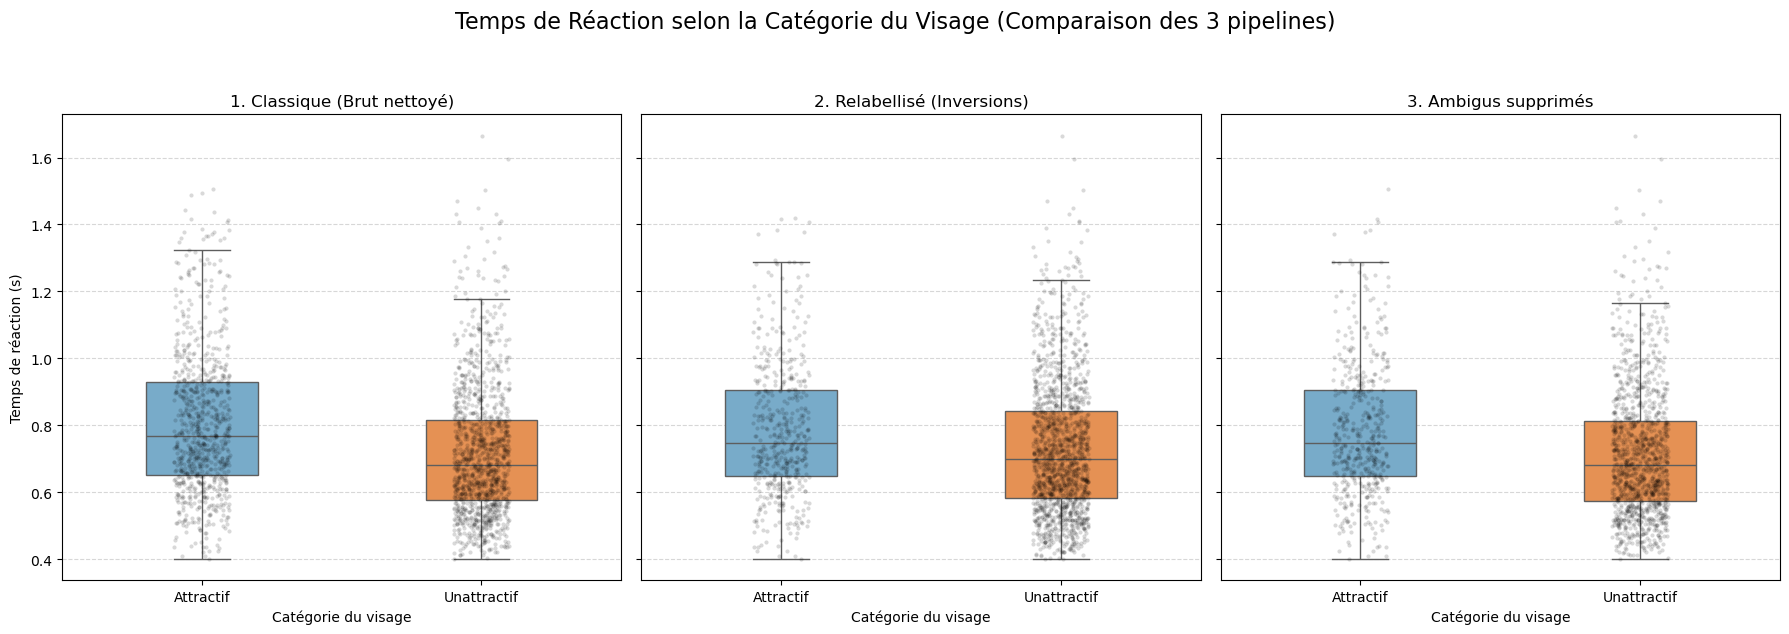

In [25]:
# Dictionnaire contenant nos 3 DataFrames nettoyés issus de l'étape précédente
datasets = {
    "1. Classique (Brut nettoyé)": df_outliers,
    "2. Relabellisé (Inversions)": df_relabel_outliers,
    "3. Ambigus supprimés": df_removelabel_outliers
}

# Couleurs pour une bonne lisibilité
palette_visage = {"Attractif": "#6baed6", "Unattractif": "#fd8d3c"}
palette_valence = {"negatif": "#e31a1c", "neutre": "#cccccc", "positif": "#238b45"}

# ==========================================
# FIGURE 1 : TR selon l'attractivité du VISAGE
# ==========================================
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig1.suptitle("Temps de Réaction selon la Catégorie du Visage (Comparaison des 3 pipelines)", fontsize=16, y=1.05)

for i, (nom, df_plot) in enumerate(datasets.items()):
    ax = axes1[i]
    
    # Boîte à moustaches (Syntaxe moderne sans FutureWarning)
    sns.boxplot(
        data=df_plot, x='label_face', y='rt',
        hue='label_face',  # NOUVEAU : On assigne x à hue
        palette=palette_visage, 
        ax=ax, width=0.4, showfliers=False,
        legend=False       # NOUVEAU : On masque la légende du boxplot
    )
    # Nuage de points superposé
    sns.stripplot(
        data=df_plot, x='label_face', y='rt',
        color='black', alpha=0.15, jitter=True, size=3, ax=ax
    )
    
    ax.set_title(nom, fontsize=12)
    ax.set_xlabel("Catégorie du visage")
    if i == 0:
        ax.set_ylabel("Temps de réaction (s)")
    else:
        ax.set_ylabel("")
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

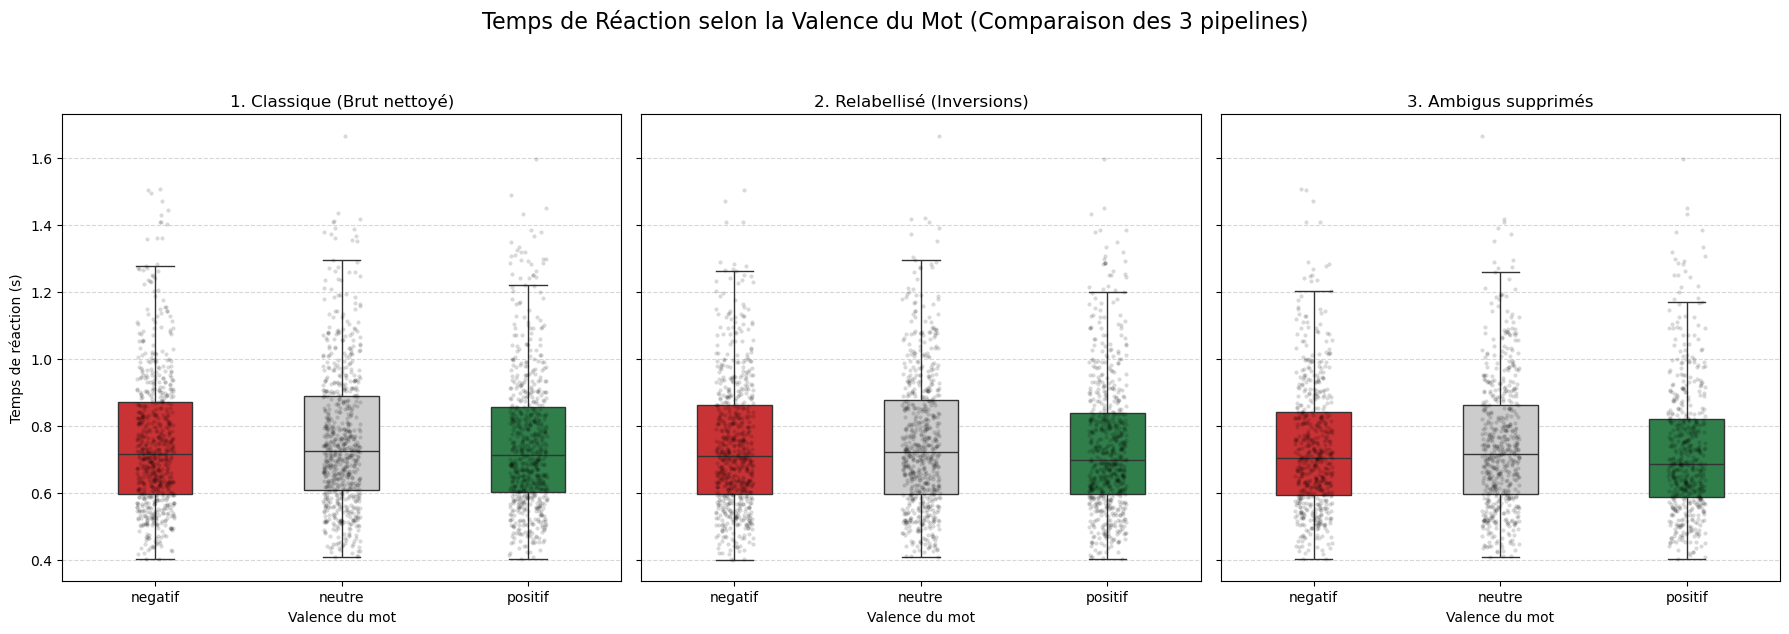

In [23]:
# ==========================================
# FIGURE 2 : TR selon la valence du MOT
# ==========================================
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig2.suptitle("Temps de Réaction selon la Valence du Mot (Comparaison des 3 pipelines)", fontsize=16, y=1.05)

# Ordre d'affichage logique pour la valence
ordre_valence = ["negatif", "neutre", "positif"]

for i, (nom, df_plot) in enumerate(datasets.items()):
    ax = axes2[i]
    
    # Boîte à moustaches (Syntaxe moderne sans FutureWarning)
    sns.boxplot(
        data=df_plot, x='valence_word', y='rt', order=ordre_valence,
        hue='valence_word', # NOUVEAU : On assigne x à hue
        palette=palette_valence, 
        ax=ax, width=0.4, showfliers=False,
        legend=False        # NOUVEAU : On masque la légende du boxplot
    )
    # Nuage de points superposé
    sns.stripplot(
        data=df_plot, x='valence_word', y='rt', order=ordre_valence,
        color='black', alpha=0.15, jitter=True, size=3, ax=ax
    )
    
    ax.set_title(nom, fontsize=12)
    ax.set_xlabel("Valence du mot")
    if i == 0:
        ax.set_ylabel("Temps de réaction (s)")
    else:
        ax.set_ylabel("")
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

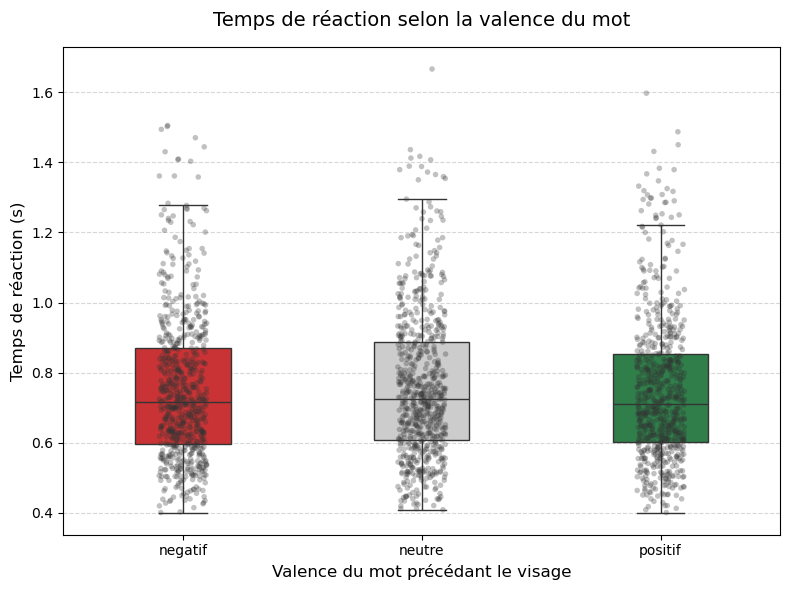

In [30]:
# ==========================================
# VISUALISATION : TR selon la valence du MOT
# ==========================================

# Ordre d'affichage logique pour l'axe des X et définition des couleurs
ordre_valence = ["negatif", "neutre", "positif"]
palette_valence = {"negatif": "#e31a1c", "neutre": "#cccccc", "positif": "#238b45"}

plt.figure(figsize=(8, 6))

# 1. Boîte à moustaches (médiane et quartiles)
sns.boxplot(
    data=df_outliers,     # Utilisez votre dataframe nettoyé principal
    x='valence_word', 
    y='rt', 
    order=ordre_valence,
    hue='valence_word',   # Syntaxe moderne pour éviter le FutureWarning
    palette=palette_valence, 
    width=0.4, 
    showfliers=False,     # On masque les points extrêmes du boxplot pour ne pas faire doublon
    legend=False
)

# 2. Nuage de points individuels (Distribution réelle)
sns.stripplot(
    data=df_outliers, 
    x='valence_word', 
    y='rt', 
    order=ordre_valence,
    hue='valence_word', 
    palette=["#333333"] * 3, # Gris foncé pour bien contraster avec les boîtes
    alpha=0.3, 
    jitter=True, 
    size=4,
    legend=False
)

# 3. Esthétique du graphique
plt.title("Temps de réaction selon la valence du mot", pad=15, fontsize=14)
plt.xlabel("Valence du mot précédant le visage", fontsize=12)
plt.ylabel("Temps de réaction (s)", fontsize=12)

# Ajout d'une grille horizontale discrète pour faciliter la lecture
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

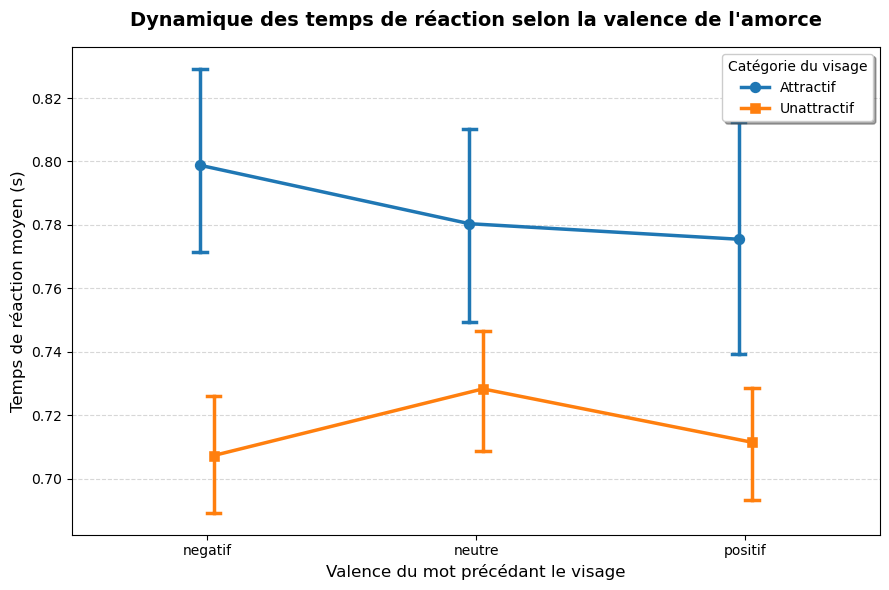

In [32]:
# ==========================================
# VISUALISATION : Courbes des Temps de Réaction
# ==========================================

# Ordre d'affichage logique pour l'axe des X
ordre_valence = ["negatif", "neutre", "positif"]

# Couleurs pour différencier les catégories de visages
palette_visage = {"Attractif": "#1f77b4", "Unattractif": "#ff7f0e"}

plt.figure(figsize=(9, 6))

# Le pointplot trace la moyenne et relie les points par une courbe.
# Par défaut, il calcule et affiche l'intervalle de confiance à 95% (les barres d'erreur).
sns.pointplot(
    data=df_removelabel_outliers, 
    x='valence_word', 
    y='rt', 
    hue='label_face',       # Une courbe par catégorie de visage
    order=ordre_valence,
    palette=palette_visage,
    dodge=0.05,             # Décale légèrement les points pour que les barres d'erreur ne se chevauchent pas
    markers=['o', 's'],     # Rond pour Attractif, Carré pour Unattractif
    capsize=0.05,           # Ajoute des petits tirets aux extrémités des barres d'erreur
    linewidth=2.5           # Épaisseur de la courbe
)

# Esthétique du graphique
plt.title("Dynamique des temps de réaction selon la valence de l'amorce", pad=15, fontsize=14, fontweight='bold')
plt.xlabel("Valence du mot précédant le visage", fontsize=12)
plt.ylabel("Temps de réaction moyen (s)", fontsize=12)

# Personnalisation de la légende et de la grille
plt.legend(title="Catégorie du visage", frameon=True, shadow=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

--- 
# Test des données les moins bruités

--- Analyse sur les stimuli les plus consensuels ---

Nombre de visages conservés (Top 25%) : 14
Moyenne d'accord des visages attractifs conservés : 0.78
Moyenne d'accord des visages unattractifs conservés : 0.98

Nombre d'essais restants après nettoyage : 544



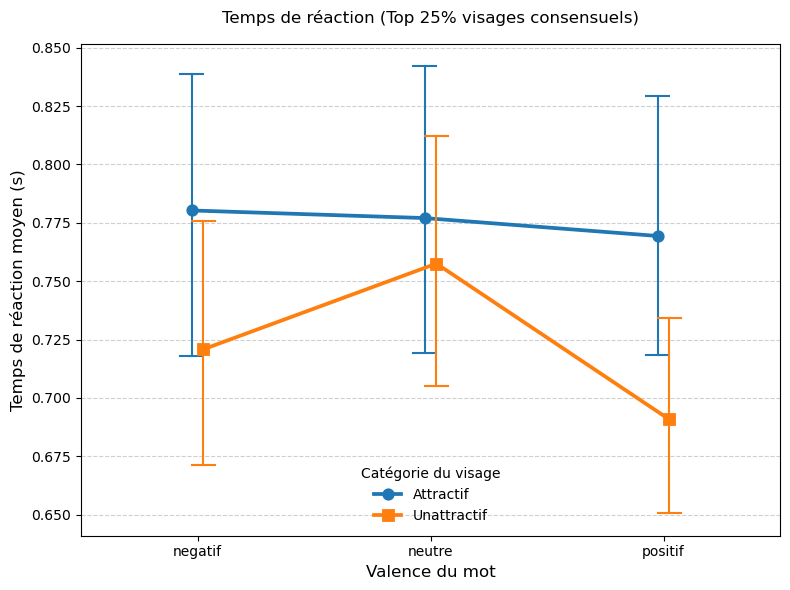

Résultats de l'ANOVA à mesures répétées sur les stimuli extrêmes :


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,ng2,eps
0,label_face,0.033258,1,21,0.033258,2.324293,0.142288,0.142288,0.009501,1.000000
1,valence_word,0.035069,2,42,0.017534,1.447640,0.246616,0.246963,0.010013,0.968749
2,label_face * valence_word,0.054438,2,42,0.027219,2.616767,0.084913,0.087108,0.015458,0.965357


In [29]:
# ==========================================
# 1. IDENTIFICATION DES STIMULI EXTRÊMES
# ==========================================
print("--- Analyse sur les stimuli les plus consensuels ---\n")

# On utilise les données brutes (avant nettoyage des TR) pour évaluer le consensus global
# df_valides contient déjà les essais où le participant a répondu (pas de "Temps écoulé")
df_valides = df[df['response_meaning'].isin(['Attractif', 'Non attractif'])].copy()

# Calcul du taux d'accord (taux de réponses correctes selon le label initial) pour chaque stimulus
taux_accord = df_valides.groupby(['label_face', 'stimulus'])['correct'].mean().reset_index()

# On sépare par catégorie pour sélectionner les meilleurs de chaque groupe
stim_attractifs = taux_accord[taux_accord['label_face'] == 'Attractif']
stim_unattractifs = taux_accord[taux_accord['label_face'] == 'Unattractif']

# On sélectionne le Top 33% (le tiers des stimuli avec le plus fort consensus)
# Vous pouvez ajuster la fraction (ex: 0.25 pour le top 25%)
fraction_top = 0.25

top_attractifs = stim_attractifs.nlargest(int(len(stim_attractifs) * fraction_top), 'correct')
top_unattractifs = stim_unattractifs.nlargest(int(len(stim_unattractifs) * fraction_top), 'correct')

# Liste des stimuli extrêmes (les plus consensuels)
stimuli_extremes = top_attractifs['stimulus'].tolist() + top_unattractifs['stimulus'].tolist()

print(f"Nombre de visages conservés (Top {fraction_top*100:.0f}%) : {len(stimuli_extremes)}")
print(f"Moyenne d'accord des visages attractifs conservés : {top_attractifs['correct'].mean():.2f}")
print(f"Moyenne d'accord des visages unattractifs conservés : {top_unattractifs['correct'].mean():.2f}\n")


# ==========================================
# 2. CRÉATION DU DATAFRAME ET NETTOYAGE
# ==========================================

# On filtre le dataframe brut pour ne garder que ces stimuli extrêmes
df_extremes = df[df['stimulus'].isin(stimuli_extremes)].copy()

# On applique notre routine de nettoyage des TR (uniquement les bonnes réponses, pas de clics impulsifs, filtre 2.5 SD)
df_extremes_clean = nettoyer_outliers_cognitifs(df_extremes)

print(f"Nombre d'essais restants après nettoyage : {len(df_extremes_clean)}\n")


# ==========================================
# 3. AGRÉGATION ET VISUALISATION
# ==========================================

# Calcul de la moyenne des TR par ID, Valence du mot et Label du visage
rt_moyens_id_extremes = (
    df_extremes_clean
    .groupby(['id', 'valence_word', 'label_face'])['rt']
    .mean()
    .reset_index(name='mean_rt')
)

plt.figure(figsize=(8, 6))

ordre_valence = ["negatif", "neutre", "positif"]

sns.pointplot(
    data=rt_moyens_id_extremes,
    x='valence_word',
    y='mean_rt',
    hue='label_face',
    order=ordre_valence,
    dodge=True,
    markers=['o', 's'],
    err_kws={'linewidth': 1.5},
    capsize=0.1
)

plt.title(f"Temps de réaction (Top {fraction_top*100:.0f}% visages consensuels)", pad=15)
plt.xlabel("Valence du mot", fontsize=12)
plt.ylabel("Temps de réaction moyen (s)", fontsize=12)
plt.legend(title="Catégorie du visage", frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# ==========================================
# 4. ANOVA SUR LES STIMULI EXTRÊMES (F1)
# ==========================================

df_anova_extremes = rt_moyens_id_extremes.dropna()

try:
    res_anova_extremes = pg.rm_anova(
        data=df_anova_extremes,
        dv='mean_rt',
        within=['label_face', 'valence_word'],
        subject='id',
        detailed=True
    )
    print("Résultats de l'ANOVA à mesures répétées sur les stimuli extrêmes :")
    display(res_anova_extremes)
except ValueError as e:
    print(f"Attention : {e}")
    print("Le filtrage extrême a probablement supprimé toutes les données d'un participant dans une condition spécifique.")